# Importación de librerias

In [22]:
from sklearn.model_selection import train_test_split 
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)
import numpy as np
import seaborn as sns

# Procesamiento de datos

## Leer Datos

In [ ]:
PATH = "../data/dataset_practica_final.csv"
data = pd.read_csv(PATH)

True
True


## Procesar datos
Extraemos los nombres de los valores posibles de la columna `is_canceled`

list_nombres_clases=data['is_canceled'].unique()

Eliminamos los valores nulos

In [13]:
data = data.dropna()

Mostramos las keys.

In [14]:
data.keys()

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

Mostramos las primeras filas.

In [15]:
data.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
2392,Resort Hotel,0,6,2015,October,42,11,2,0,2,...,No Deposit,240.0,113.0,0,Transient,82.0,1,1,Check-Out,2015-10-13
2697,Resort Hotel,0,24,2015,October,44,26,7,15,1,...,No Deposit,185.0,281.0,0,Transient-Party,52.2,0,0,Check-Out,2015-11-17
2867,Resort Hotel,0,24,2015,November,45,3,0,3,2,...,No Deposit,334.0,281.0,0,Transient-Party,48.0,0,0,Check-Out,2015-11-06
2877,Resort Hotel,0,24,2015,November,45,3,2,10,1,...,No Deposit,328.0,281.0,0,Transient-Party,40.0,0,0,Check-Out,2015-11-15
2878,Resort Hotel,0,24,2015,November,45,3,3,10,2,...,No Deposit,326.0,281.0,0,Transient-Party,48.0,0,0,Check-Out,2015-11-16


Mostramos la dimensión del conjunto de datos

In [18]:
data.shape

(217, 32)

Mostramos las información de las columnas del conjunto de datos.

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 217 entries, 2392 to 116451
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           217 non-null    object 
 1   is_canceled                     217 non-null    int64  
 2   lead_time                       217 non-null    int64  
 3   arrival_date_year               217 non-null    int64  
 4   arrival_date_month              217 non-null    object 
 5   arrival_date_week_number        217 non-null    int64  
 6   arrival_date_day_of_month       217 non-null    int64  
 7   stays_in_weekend_nights         217 non-null    int64  
 8   stays_in_week_nights            217 non-null    int64  
 9   adults                          217 non-null    int64  
 10  children                        217 non-null    float64
 11  babies                          217 non-null    int64  
 12  meal                            217

Descripción estadística de las columnas numéricas.

In [19]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
is_canceled,217.0,0.078341,0.269329,0.0,0.0,0.0,0.0,1.0
lead_time,217.0,40.520737,61.748375,0.0,12.0,27.0,36.0,364.0
arrival_date_year,217.0,2015.465438,0.720053,2015.0,2015.0,2015.0,2016.0,2017.0
arrival_date_week_number,217.0,38.198157,12.890292,1.0,33.0,45.0,46.0,53.0
arrival_date_day_of_month,217.0,10.824885,7.582065,1.0,6.0,9.0,13.0,31.0
stays_in_weekend_nights,217.0,1.566820,1.492700,0.0,0.0,2.0,2.0,9.0
stays_in_week_nights,217.0,4.631336,3.552846,0.0,2.0,4.0,6.0,21.0
adults,217.0,1.410138,0.520406,1.0,1.0,1.0,2.0,3.0
children,217.0,0.036866,0.232788,0.0,0.0,0.0,0.0,2.0
babies,217.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


Obtenemos las frecuencias absolutas de la columna `is_canceled`

In [20]:
data['is_canceled'].value_counts()

is_canceled
0    200
1     17
Name: count, dtype: int64

Obtenemos las frecuencias relativas de la columna `is_canceled`

In [21]:
data['is_canceled'].value_counts(normalize=True)

is_canceled
0    0.921659
1    0.078341
Name: proportion, dtype: float64

Visualización de las variables numéricas con un gráfico de dispersión distinguiendo por la clase.

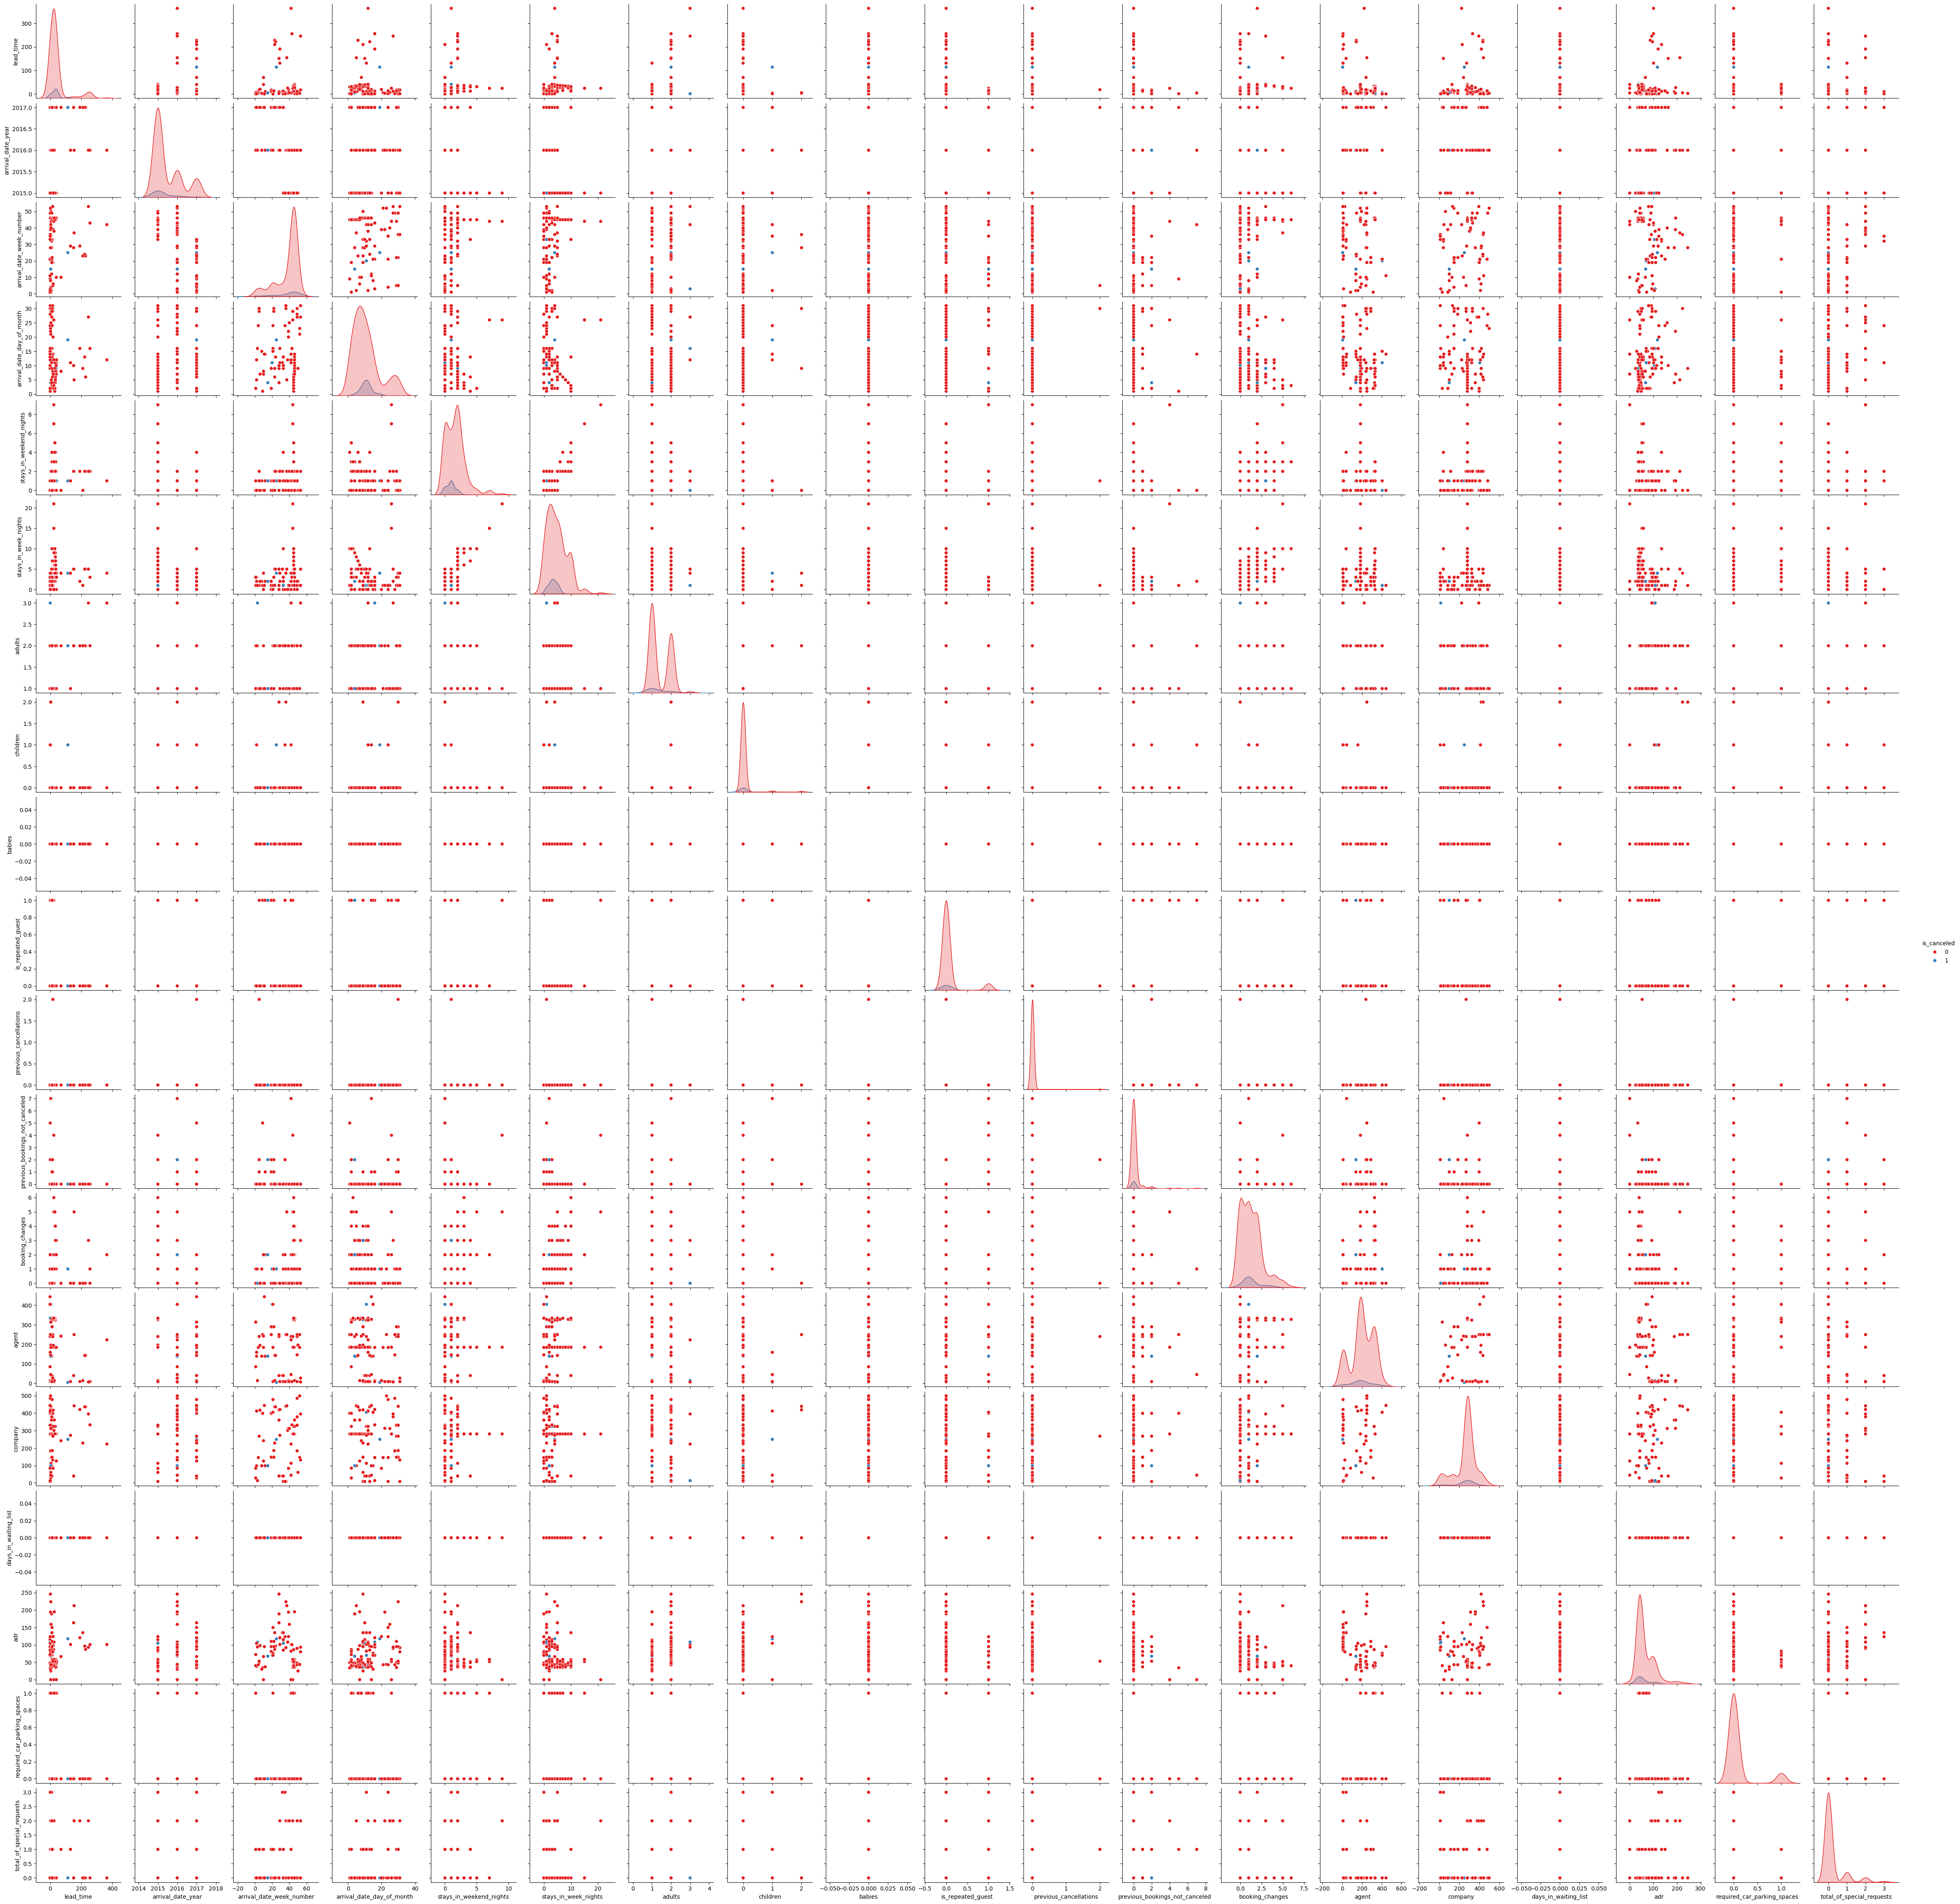

In [23]:
sns.pairplot(data, hue='is_canceled', palette='Set1')

Eliminamos las columnas `is_canceled`, `reservation_status` y `reservation_satus_date` del conjunto de datos y los almacenamos en la variable `X`. Convertimos las variables categóricas en variables numéricas mediante one-hot encoding de la variable `X`. Almacenamos en la variable `y` la columna ìs_canceled`. 

In [25]:
X = data.drop(columns=["is_canceled", "reservation_status", "reservation_status_date"])
X = pd.get_dummies(X, drop_first=True)
y = data['is_canceled']

Extraemos los valores posibles de la columna `is_canceled`

In [30]:
list_nombres_clases=data['is_canceled'].unique()

Dividimos los conjuntos `X` e `y` en los subconjuntos de prueba y entrenamiento. 

In [26]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Entrenamiento de modelos

### Arbol de Decisión

Configuramos el modelo y lo entrenamos.

In [27]:
modelo_dt = DecisionTreeClassifier(max_depth=3, min_samples_split=20, min_samples_leaf=10, random_state=42)
modelo_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

Calculamos la predicción y la probabilidad de pertencia a la primera clase.

In [28]:
y_pred = modelo_dt.predict(X_test)
y_proba = modelo_dt.predict_proba(X_test)[:, 1]

Sacamos un gráfico del arbol de decisión.

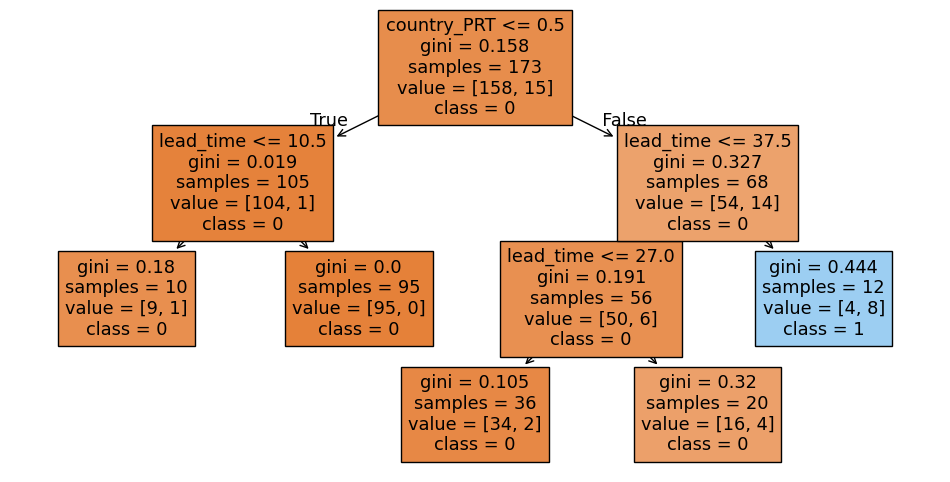

In [29]:
plt.figure(figsize=(12,6))
plot_tree(modelo_dt, feature_names=X_train.columns.to_list(), class_names=['0', '1'], filled=True)
plt.show()

Calculamos las métricas de este modelo.

In [31]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  93.18%
Precisión: 91.01%
Recall:    0.93
F1-Score:  0.92
AUC:       0.77



Hayamos la matriz de confusión. 

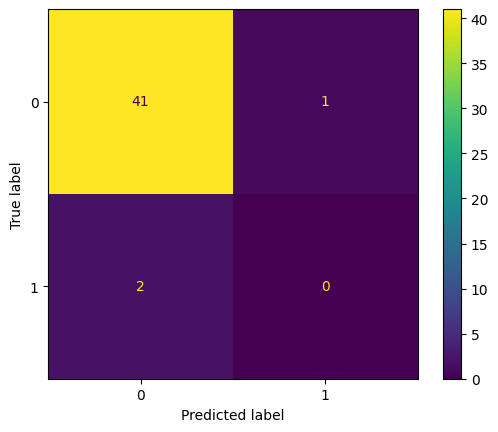

In [32]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

Hayamos la curva de ROC.

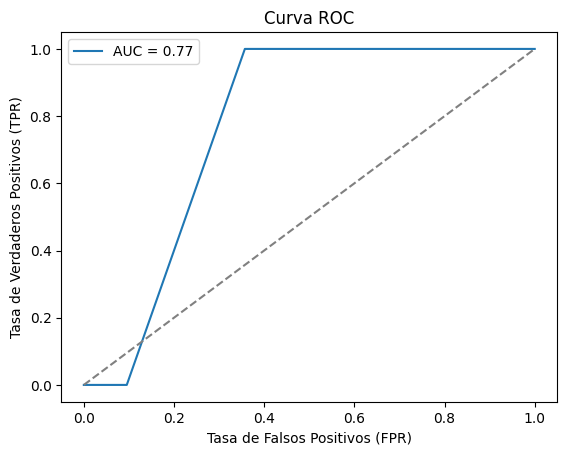

In [33]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Clasificación Binaria

Configuramos el modelo y lo entrenamos. Escalamos los datos para obtener un mejor resultado. 

In [39]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
modelo_rl = LogisticRegression(max_iter=200, random_state=42)
modelo_rl.fit(X_train,y_train)

LogisticRegression(max_iter=200, random_state=42)

Calculamos la predicción y la probabilidad de pertencia a la primera clase. Con ravel convertimos un array de varias dimensiones en un vector de una sola dimensión. En y_pred comparando la probabilidad de pertenencia a una clase y le asiganamos un True o False en función del resultado, y lo convertimos a 0 o 1. 

In [42]:
y_proba = modelo_rl.predict(X_test).ravel()
y_pred = (y_proba > 0.5).astype(int)

Calculamos las métricas de este modelo.

In [43]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  95.45%
Precisión: 95.45%
Recall:    0.95
F1-Score:  0.95
AUC:       0.74



Hayamos la matriz de confusión. 

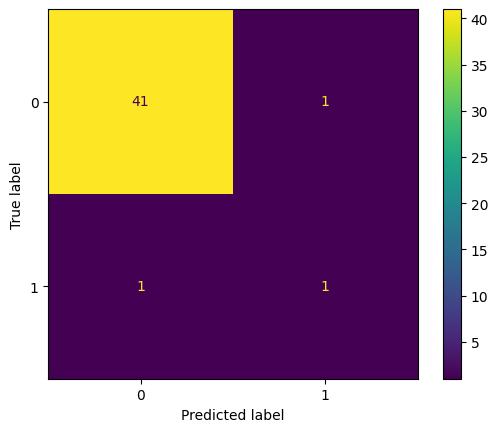

In [44]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

Hayamos la curva de ROC.

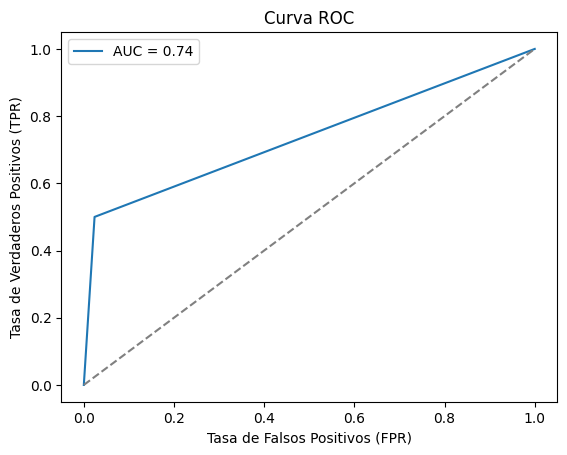

In [45]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Random Forest

Configuramos el modelo y lo entrenamos.

In [46]:
modelo_rfc = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_leaf=5, random_state=42)
modelo_rfc.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, n_estimators=200,
                       random_state=42)

Calculamos la predicción y la probabilidad de pertencia a la primera clase.

In [47]:
y_pred = modelo_rfc.predict(X_test)
y_proba = modelo_rfc.predict_proba(X_test)[:, 1]

Calculamos las métricas de este modelo.

In [48]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  95.45%
Precisión: 91.12%
Recall:    0.95
F1-Score:  0.93
AUC:       0.77



c:\Users\Javi\Desktop\Máster en IA, CLOUD COMPUTING & DEVOPS\T5 Machine Learning y Deep Learning\Practica\Pontia\env-pontia-ai\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hayamos la matriz de confusión. 

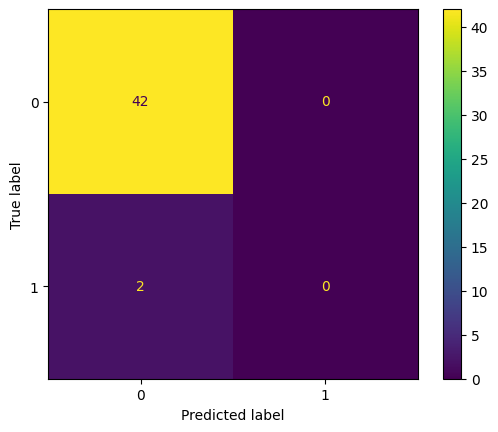

In [49]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

Hayamos la curva de ROC.

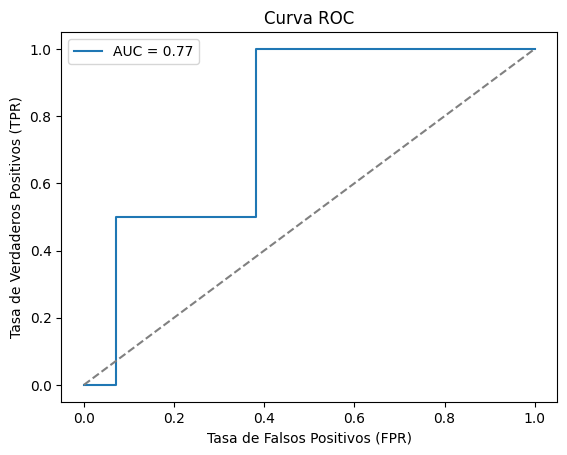

In [50]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

### XGBC

Configuramos el modelo y lo entrenamos.

In [51]:
modelo_xgbc = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, eval_metric='logloss', random_state=42)
modelo_xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

Calculamos la predicción y la probabilidad de pertencia a la primera clase.

In [54]:
y_pred = modelo_xgbc.predict(X_test)
y_proba = modelo_xgbc.predict_proba(X_test)[:, 1]

Calculamos las métricas de este modelo.

In [55]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  93.18%
Precisión: 91.01%
Recall:    0.93
F1-Score:  0.92
AUC:       0.73



Hayamos la matriz de confusión. 

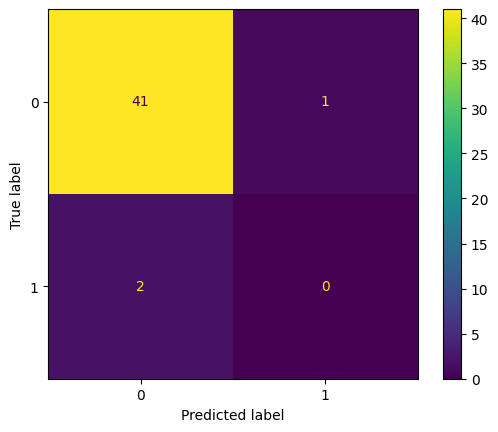

In [56]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

Hayamos la curva de ROC.

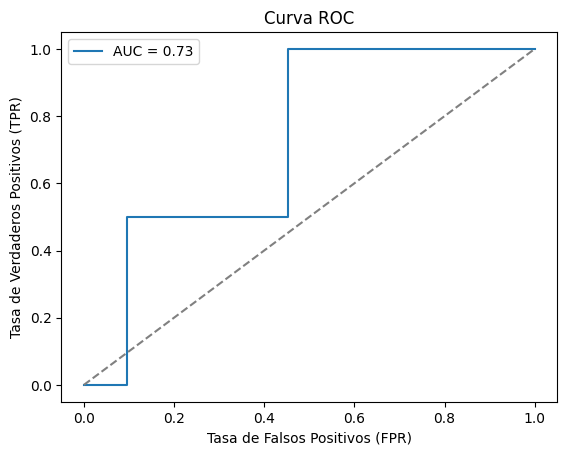

In [57]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

### Red Neuronal Multicapa

Configuramos el modelo y lo entrenamos. Escalamos los datos para obtener un mejor resultado. Se compone de 5 capas, la de entrada, 3 ocultas con la función relu y la de salida con la dunción sigmoid. Optimizamos el modelo con Adam, en la perdida aplicamos `binary_crossentropy` y en metrica `accuracy`. Ademas mostramos un resumen de las capas con la función `summary`. 

In [65]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model_rnm = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1], ), name='i1'),
        tf.keras.layers.Dense(128, activation='relu', name='h1'),
        tf.keras.layers.Dense(64, activation='relu', name='h2'),
        tf.keras.layers.Dense(32, activation='relu', name='h3'),
        tf.keras.layers.Dense(1, activation='sigmoid',name='o1'),
])
optimizer_adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model_rnm.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=['accuracy'])
model_rnm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 128)            │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h3 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o1 (Dense)                      │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,225 (79.00 KB)

 Trainable params: 20,225 (79.00 KB)

 Non-trainable params: 0 (0.00 B)

Calculamos la predicción y la probabilidad de pertencia a la primera clase. Con ravel convertimos un array de varias dimensiones en un vector de una sola dimensión. En y_pred comparando la probabilidad de pertenencia a una clase y le asiganamos un True o False en función del resultado, y lo convertimos a 0 o 1. 

In [66]:
y_proba = model_rnm.predict(X_test).ravel()
y_pred = (y_proba > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


Calculamos las métricas de este modelo.

In [67]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted")
rec = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")
auc = roc_auc_score(y_test, y_proba)
print(f"Accuracy:  {acc:.2%}")
print(f"Precisión: {prec:.2%}")
print(f"Recall:    {rec:.2f}")
print(f"F1-Score:  {f1:.2f}")
print(f"AUC:       {auc:.2f}\n")

Accuracy:  95.45%
Precisión: 91.12%
Recall:    0.95
F1-Score:  0.93
AUC:       0.89



c:\Users\Javi\Desktop\Máster en IA, CLOUD COMPUTING & DEVOPS\T5 Machine Learning y Deep Learning\Practica\Pontia\env-pontia-ai\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Hayamos la matriz de confusión. 

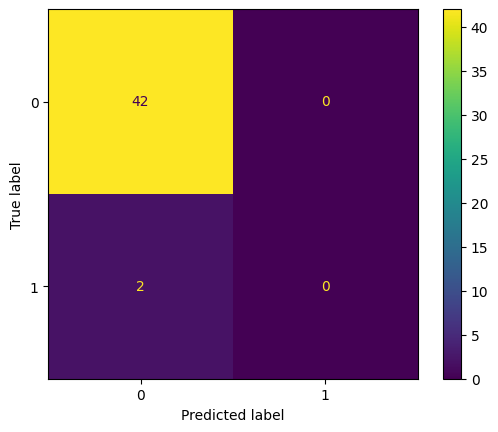

In [68]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list_nombres_clases)
disp.plot()
plt.show()

Hayamos la curva de ROC.

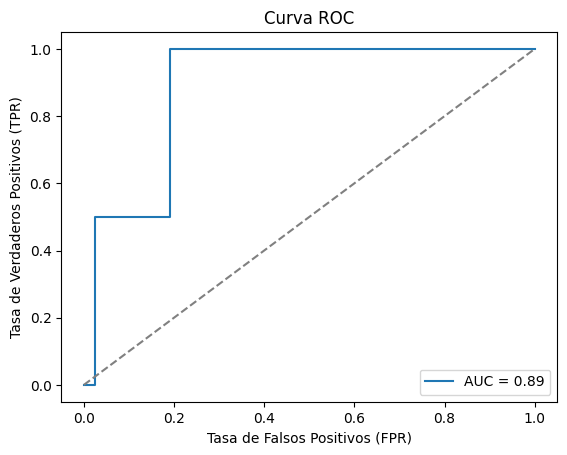

In [69]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()